In [4]:
import numpy as np
import scipy.special

import networkx as nx


import matplotlib.pyplot as plt

In [5]:
def wealth_hist_and_tail_fit(wealth, w_min=None):
    """
    From integer wealth array, compute N(w) = number of people with wealth w,
    and fit the tail N(w) ~ C * w^{-alpha} for w >= w_min.
    Returns (w_vals, counts, alpha, C, w_min).
    """
    wealth = np.asarray(wealth, dtype=int)

    # Histogram over integer wealth: index = wealth, value = count
    counts_all = np.bincount(wealth)      
    w_vals = np.arange(counts_all.size)[1:]   # drop wealth=0
    counts = counts_all[1:]

    # Choose a tail threshold if not provided (default: top 5% by wealth)
    if w_min is None:
        w_min = max(2, int(np.percentile(wealth, 95)))

    # Tail selection + filter zeros
    tail_mask = (w_vals >= w_min) & (counts > 0)
    x = np.log(w_vals[tail_mask])
    y = np.log(counts[tail_mask])

    if len(x) < 2:
        raise ValueError("Not enough nonzero tail bins to fit!")

    # Linear fit in log–log space: log N(w) = log C + (-alpha) * log w
    slope, intercept = np.polyfit(x, y, 1)
    alpha = -slope
    C = np.exp(intercept)

    # Plot: histogram counts and fitted tail
    plt.figure()
    plt.loglog(w_vals, counts, 'o', ms=3, label='count N(w)')
    plt.loglog(w_vals[tail_mask], C * w_vals[tail_mask]**(-alpha),
               '-', label=f'fit: α ≈ {alpha:.2f}, w_min={w_min}')
    plt.xlabel('wealth w')
    plt.ylabel('count N(w)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return w_vals, counts, alpha, C, w_min

Final number of people: 49989
Total wealth: 100001 (should be 100001)
Top 5 fortunes: [640, 254, 173, 161, 135]


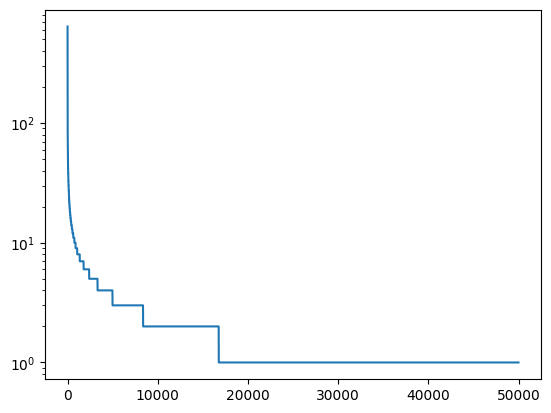

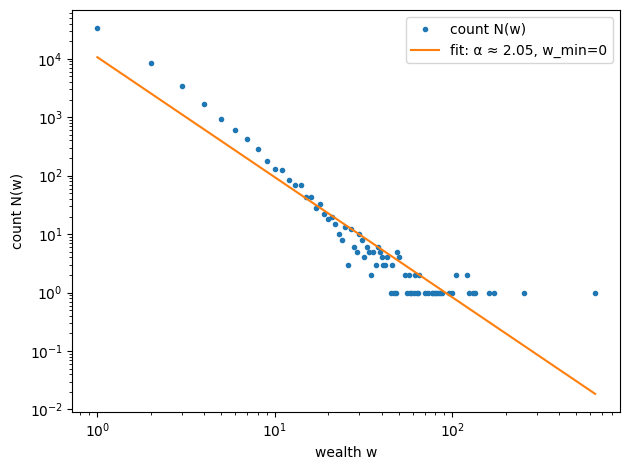

In [8]:
def simulate_simon(p=0.95, T=100_000, seed=None, track=None):
    """
    Herbert Simon (1955) preferential growth / 'rich get richer' model.

    At each step we add $1:
      - with prob p: give it to an existing person chosen with probability
        proportional to their wealth
      - with prob (1-p): create a new person with initial wealth 1

    Args
    ----
    p : float in (0,1)
        Probability of giving to an existing person.
    T : int
        Number of $1 increments (iterations).
    seed : int or None
        RNG seed for reproducibility.
    track : None or dict
        If dict (e.g. {}), will be filled with simple time series like
        number of people and Gini coefficient.

    Returns
    -------
    wealth : np.ndarray, shape (N_people,)
        Final wealths (unsorted, dtype=int).
    """
    if not (0 < p < 1):
        raise ValueError("p must be in (0,1)")
    rng = np.random.default_rng(seed)

    # start with one person holding $1
    wealth = np.array([1], dtype=np.int64)
    total = 1

    if isinstance(track, dict):
        track["t"] = []
        track["N"] = []
        track["gini"] = []

    for t in range(T):
        if rng.random() < p:
            # choose existing person with probability ∝ wealth
            idx = rng.choice(wealth.size, p=wealth / total)
            wealth[idx] += 1
            total += 1
        else:
            # add a new person with wealth 1
            wealth = np.append(wealth, 1)
            total += 1


        if isinstance(track, dict) and (t % max(1, T // 1000) == 0):
            w = wealth
            # Gini (vectorized; robust for ints)
            if w.size > 0:
                w_sorted = np.sort(w)
                n = w_sorted.size
                cumw = np.cumsum(w_sorted, dtype=np.float64)
                gini = (n + 1 - 2 * (cumw / cumw[-1]).sum()) / n
            else:
                gini = np.nan
            track["t"].append(t + 1)
            track["N"].append(wealth.size)
            track["gini"].append(gini)

    return wealth


p = 0.5        # "rarely give to the poor"
T = 100000     # number of $1 steps
wealth = simulate_simon(p=p, T=T, seed=42)

# Basic summaries
print(f"Final number of people: {wealth.size}")
print(f"Total wealth: {wealth.sum()} (should be {T+1})")
top5 = np.sort(wealth)[-5:][::-1]
print("Top 5 fortunes:", top5.tolist())

# If you want the (rank, wealth) data:
ranks = np.arange(1, wealth.size + 1)
wealth_sorted = np.sort(wealth)[::-1]

plt.plot(wealth_sorted)
plt.yscale("log")
plt.show()
_ = wealth_hist_and_tail_fit(wealth, w_min=0) # set w_min yourself, or leave None

